In [1]:
import os
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")
import sys
import numpy as np
import pandas as pd

In [2]:
import scanpy as sc
import palantir

In [3]:
import matplotlib.pyplot as plt

# read the cellbarcode and compute density

In [6]:
ad = sc.read_h5ad("data/combined_filt.h5ad")

In [ ]:
ery_mk = pd.read_csv("data/input_pseudo_dyn_ery_mk_dpt_feb_22_with_index.csv", index_col=0)
ery_mk_ad = ad[ery_mk.index].copy()
ery_mk_ad.obs['branch'] = ery_mk.loc[ery_mk_ad.obs_names, 'pseudodynamics_branch_class'].values
ery_mk_ad

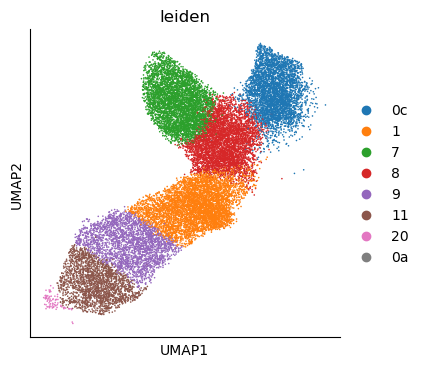

In [27]:
sc.pl.umap(ery_mk_ad, color='leiden')

In [92]:
import seaborn as sns

In [96]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [ ]:
fig, axs = plt.subplots(3, 9, figsize=(19,5),  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(ery_mk_ad.obs['timepoint_tx_days'].unique()):
    obs_t = ery_mk_ad.obs.query("`timepoint_tx_days` == @t")

    #  fate probability density
    # sns.kdeplot(ad_t.obsm['palantir_fate_probabilities']['mk'], ax=axs[0,i_t], label='mk')
    
    sns.kdeplot(obs_t.dpt_pseudotime.values, ax=axs[0, i_t], label='ery')
    
    sns.kdeplot(obs_t.query("`branch` != 'mk'").dpt_pseudotime.values, ax=axs[1, i_t], label='ery')

    #  plt
    # sns.kdeplot(ad_t[ad_t.obsm['branch_masks']['mk']].obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='mk')
    sns.kdeplot(obs_t.query("`branch` != 'ery'").dpt_pseudotime.values, ax=axs[2, i_t], label='mk')



In [ ]:
fig, axs = plt.subplots(3, 9, figsize=(19,5), sharey=True,  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(ery_mk_ad.obs['timepoint_tx_days'].unique()):
    obs_t = ery_mk_ad.obs.query("`timepoint_tx_days` == @t")

    #  fate probability density
    # sns.kdeplot(ad_t.obsm['palantir_fate_probabilities']['mk'], ax=axs[0,i_t], label='mk')
    
    sns.kdeplot(obs_t.dpt_pseudotime.values, ax=axs[0, i_t], label='ery')
    
    sns.kdeplot(obs_t.query("`branch` != 'mk'").palantir_pseudotime.values, ax=axs[1, i_t], label='ery')

    #  plt
    # sns.kdeplot(ad_t[ad_t.obsm['branch_masks']['mk']].obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='mk')
    sns.kdeplot(obs_t.query("`branch` != 'ery'").palantir_pseudotime.values, ax=axs[2, i_t], label='mk')



# run palantir

In [11]:
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [12]:
ery_mk_ad.uns['iroot'] = ery_mk_ad.obs['HSCscore'].argmax()

In [13]:
ery_mk_ad.uns['iroot']

4866

In [14]:
sc.pp.neighbors(ery_mk_ad, use_rep='X_pca_harmony', n_neighbors=30)

In [15]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(ery_mk_ad, pca_key='X_pca_harmony',n_components=5)
ms_data = palantir.utils.determine_multiscale_space(ery_mk_ad)

In [16]:
dm_res['EigenVectors'].shape

(22740, 5)

In [17]:
ms_data.shape

(22740, 3)

### magic impute expression

(<Figure size 1500x300 with 5 Axes>,
 {0: <Axes: title={'center': 'Component 0'}>,
  1: <Axes: title={'center': 'Component 1'}>,
  2: <Axes: title={'center': 'Component 2'}>,
  3: <Axes: title={'center': 'Component 3'}>,
  4: <Axes: title={'center': 'Component 4'}>})

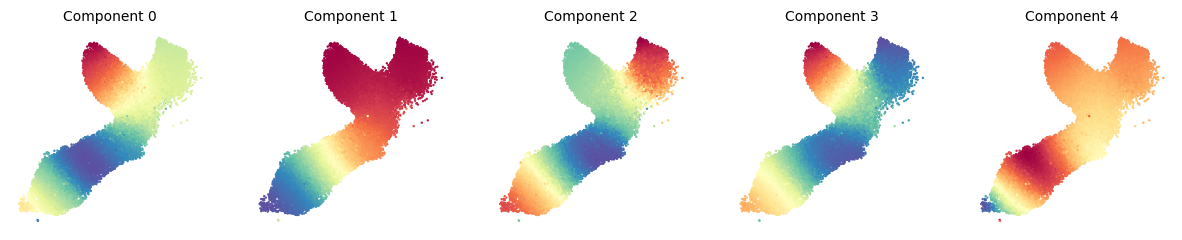

In [18]:
imputed_X = palantir.utils.run_magic_imputation(ery_mk_ad)
palantir.plot.plot_diffusion_components(ery_mk_ad)

In [19]:
print(ery_mk_ad.obsm['DM_EigenVectors'].shape)
print(ery_mk_ad.obsm['DM_EigenVectors_multiscaled'].shape)

(22740, 5)
(22740, 3)


In [23]:
ery_mk = pd.read_csv("data/input_pseudo_dyn_ery_mk_dpt_feb_22_with_index.csv", index_col=0)

# terminal mk
mk_terminal_idx = ery_mk.query('`pseudodynamics_branch_class` == "mk"').dpt_pseudotime.argmax()
mk_terminal_cb = ery_mk.query('`pseudodynamics_branch_class` == "mk"').iloc[mk_terminal_idx].name
print(mk_terminal_cb)

# terminal ery
ery_terminal_idx = ery_mk.query('`pseudodynamics_branch_class` == "ery"').dpt_pseudotime.argmax()
ery_terminal_cb = ery_mk.query('`pseudodynamics_branch_class` == "ery"').iloc[ery_terminal_idx].name
print(ery_terminal_cb)

# root
root_idx = ery_mk_ad.uns['iroot']
root_cb = ery_mk_ad.obs_names[root_idx]
print(root_cb)

5mo_SIGAD9_CCCTAACGTTCTCACC-1-10x
9mo_SIGAE3_TCTAACTGTCGTCATA-1-10x
9mo_SIGAF3_CTCCATGTCACAGTGT-1-10x


In [24]:
all_states = pd.Series(
    ["mk", "ery", "root"],
    index=[mk_terminal_cb, ery_terminal_cb, root_cb],
)

terminal_states = pd.Series(
    ["mk", "ery"],
    index=[mk_terminal_cb, ery_terminal_cb],
)

In [ ]:
palantir.plot.highlight_cells_on_umap(ery_mk_ad, all_states)
plt.show()

In [26]:
start_cell = root_cb
pr_res = palantir.core.run_palantir(
    ery_mk_ad, start_cell, num_waypoints=500, terminal_states=terminal_states
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.03706576029459636 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.719346841176351 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [ ]:
palantir.plot.plot_palantir_results(ery_mk_ad, s=3)
plt.show()

In [ ]:
sc.pl.umap(ery_mk_ad, color=['palantir_pseudotime'], )

In [30]:
ery_mk_ad.uns['pop']

{'mean': array([   68.71174149,   181.0456594 ,   319.71192389,  1033.80104176,
         1221.63752755,  4388.82149907,  6420.56721147,  2300.67040713,
        18898.77670928]),
 'n_lib': array([4, 6, 4, 4, 4, 2, 4, 4, 4]),
 't': array([  3,   7,  12,  27,  49,  76, 112, 161, 269]),
 'var': array([5.64698791e+01, 2.97828935e+02, 7.21614187e+02, 2.48259499e+04,
        2.60310172e+04, 1.62207978e+04, 4.28322705e+05, 1.26096766e+05,
        3.51421915e+05])}

In [10]:
ery_mk_ad.write_h5ad('data/ery_mk_Aug1.h5ad')

# branch

In [36]:
masks = palantir.presults.select_branch_cells(ery_mk_ad, q=.02, eps=.02)

In [ ]:
palantir.plot.plot_branch_selection(ery_mk_ad)
plt.show()

In [ ]:
palantir.plot.plot_trajectory(ery_mk_ad, "ery")

In [ ]:
palantir.plot.plot_trajectory(ery_mk_ad, "mk")

# cell rank

In [4]:
ery_mk_ad = sc.read_h5ad('data/ery_mk_Aug1.h5ad')

In [9]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

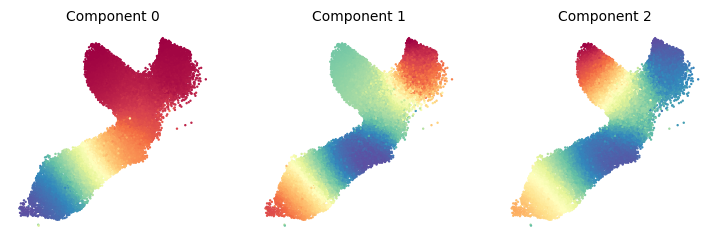

In [31]:
palantir.plot.plot_diffusion_components(ery_mk_ad, dm_res='DM_EigenVectors_multiscaled')
plt.show()

In [36]:
ery_mk_ad.obsm['DM_EigenVectors_multiscaled'].shape

(22740, 3)

In [38]:
print(ery_mk_ad.obsm['DM_EigenVectors_multiscaled'].std(axis=0))

[2.6396816  0.6617021  0.65143204]


In [35]:
print(ery_mk_ad.obsm['DM_EigenVectors'].std(axis=0))

[1.5935826e-06 6.6313911e-03 6.6313827e-03 6.6313832e-03 6.6313078e-03]


In [39]:
# transition matrix
import cellrank as cr
import scvelo as scv
import PINN

In [46]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [69]:
ck = cr.kernels.ConnectivityKernel(ery_mk_ad)
ck.compute_transition_matrix()

pk = cr.kernels.PseudotimeKernel(ery_mk_ad, time_key="palantir_pseudotime")
pk.compute_transition_matrix(threshold_scheme='soft')

  0%|          | 0/22740 [00:00<?, ?cell/s]

PseudotimeKernel[n=22740, dnorm=False, scheme='soft', b=10.0, nu=0.5]

In [ ]:
pk.plot_projection()

combined_kernel = ck *0.8 + pk*0.2
combined_kernel.compute_transition_matrix()
combined_kernel.plot_projection()

In [63]:
from PINN.functions import reader_funs

In [70]:
T_M = pk.transition_matrix
cellstate_key = 'DM_EigenVectors'
delta_DM, neighbors = reader_funs.sample_deltax_from_transition(ery_mk_ad, T_M, xkey=cellstate_key)

cellstate_ad = PINN.tl.make_coord_adata(ery_mk_ad, cellstate_key=cellstate_key, n_dimension=7)
cellstate_ad.layers['velocity'] = delta_DM


# compute velocity graph
vkey = 'velocity'
scv.tl.velocity_graph(cellstate_ad,  vkey='velocity', xkey='cellstate', n_jobs=20)

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


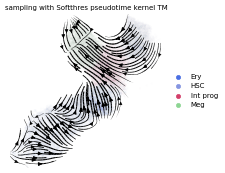

In [72]:
# vis
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title='sampling with Softthres pseudotime kernel TM ', )
                                # save=f"{result_dir}/{vkey}_velo.png")

In [79]:
knn_dx = []
for i in range(20):
    knn_delta_dm, neighbors = reader_funs.sample_deltax_from_knn(ery_mk_ad, T_M, xkey=cellstate_key, temperature=1, progressbar=False)
    knn_dx.append(knn_delta_dm)

knn_dx = np.stack(knn_dx)

In [76]:
knn_dx.shape

(10, 22740, 5)

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

5087.72s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5087.90s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.09s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.26s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.45s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.63s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.81s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5088.98s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5089.16s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5089.34s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
5089.52s - pydevd: Sending message related to proc

    finished (0:00:23) --> added 
    'velocity from KNN sampled idx_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:06) --> added
    'velocity from KNN sampled idx_umap', embedded velocity vectors (adata.obsm)


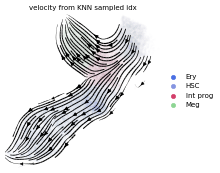

In [ ]:
# compute velocity graph
vkey = 'velocity from KNN sampled idx'

cellstate_key = 'DM_EigenVectors'
cellstate_ad.layers[vkey] = knn_dx.mean(axis=0)
scv.tl.velocity_graph(cellstate_ad,  vkey=vkey, xkey='cellstate', n_jobs=20)
# vis
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title=vkey, )
                                # save=f"{result_dir}/{vkey}_velo.png")

In [ ]:
ery_mk_ad.obsm['delta_DM'] = knn_dx.mean(axis=0)

## DM eigen vector scaled by std

In [94]:
DM = ery_mk_ad.obsm['DM_EigenVectors'].copy()
ery_mk_ad.obsm['DM_EigenVectors_scaled'] = DM / DM.std(axis=0)

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

7634.44s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7634.61s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7634.80s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7634.98s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.17s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.35s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.53s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.71s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7635.89s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7636.29s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
7636.48s - pydevd: Sending message related to proc

    finished (0:00:23) --> added 
    'velocity from KNN sampled idx_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:04) --> added
    'velocity from KNN sampled idx_umap', embedded velocity vectors (adata.obsm)


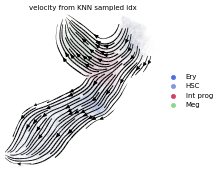

In [95]:
# compute velocity graph
vkey = 'velocity from KNN sampled idx'
cellstate_key = 'DM_EigenVectors_scaled'

# sample
knn_dx_scaled = []
for i in range(20):
    knn_delta_dm, neighbors = reader_funs.sample_deltax_from_knn(ery_mk_ad, T_M, xkey=cellstate_key, temperature=1, progressbar=False)
    knn_dx_scaled.append(knn_delta_dm)

knn_dx_scaled = np.stack(knn_dx_scaled)


# 
cellstate_ad = PINN.tl.make_coord_adata(ery_mk_ad, cellstate_key=cellstate_key, n_dimension=5)
cellstate_ad.layers[vkey] = knn_dx_scaled.mean(axis=0)


# vis
scv.tl.velocity_graph(cellstate_ad,  vkey=vkey, xkey='cellstate', n_jobs=20)
fig_velocity = plt.figure(dpi=50, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color='anno_man', vkey=vkey, 
                                basis='umap', ax=ax, 
                                legend_loc='right', alpha=0.01,
                                title=vkey, )
                                # save=f"{result_dir}/{vkey}_velo.png")

In [221]:
ery_mk_ad.obs['timepoint_tx_days'] = ery_mk_ad.obs['timepoint_tx_days'].astype(int)

In [222]:
ery_mk_ad.write_h5ad('data/ery_mk_Aug1.h5ad')

# check density

In [209]:
from PINN import reader

In [ ]:
for space in ['DM_EigenVectors', 'DM_EigenVectors_scaled', 'DM_EigenVectors_multiscaled']:

    full_DS = reader.TwoTimpepoint_AnnDS(
                                AnnData=ery_mk_ad, 
                                split = None,
                                n_dimension = None,
                                cellstate_key= space,
                                log_transform=False,
                                norm_time=True,
                                deltax_key='Delta_DM',
                                # kde_kws = {'bw_method':1},
                                batchsize=300)
                                
    PINN.pl.params_in_umap(ery_mk_ad, full_DS.u_b, param='u');

In [ ]:
full_DS_volume = reader.TwoTimpepoint_AnnDS(
                            AnnData=ery_mk_ad, 
                            knn_volume = True, #!!!!! THIS ARG
                            split = None,
                            n_dimension = None,
                            cellstate_key= 'DM_EigenVectors_scaled',
                            log_transform=False,
                            norm_time=True,
                            deltax_key='Delta_DM',
                            batchsize=300)
                            
PINN.pl.params_in_umap(ery_mk_ad, full_DS_volume.u_b, param='volumed scaled u');
PINN.pl.params_in_umap(ery_mk_ad, np.log(full_DS_volume.u_b+1e-9), param='volumed scaled u');

# test KNN distance for correcting KDE Density

In [ ]:
X =  ery_mk_ad.obsm['DM_EigenVectors_scaled'].copy()
dist = ery_mk_ad.obsp['distances'].copy()
conn = ery_mk_ad.obsp['connectivities'].copy()

In [ ]:
dist = ery_mk_ad.obsp['distances'].copy()
conn = ery_mk_ad.obsp['connectivities'].copy()

Vol = []
DM_vol = []
DM_vol_mean = []
for i in range(dist.shape[0]):
    nz_dist_u = dist[i].data
    r1 = nz_dist_u[np.nonzero(nz_dist_u)].min()
    r2 = nz_dist_u.max()
    Vol.append(np.sqrt(r1*r2))
    
    DM_dist = np.sum((X[conn[i].indices] - X[[i]])**2,axis=1)*0.5
    min_DMdist = DM_dist[np.nonzero(DM_dist)].min()
    max_DMdist = DM_dist.max()
    DM_vol.append(np.sqrt(min_DMdist*max_DMdist))
    DM_vol_mean.append( DM_dist.mean() )

vol = np.array(Vol)
DM_vol = np.array(DM_vol)
DM_vol_mean = np.array(DM_vol_mean)

# KNN distance in PCA space

In [ ]:
ery_mk_ad.obs['PCA_volume'] = vol

thres = np.quantile(Vol, 0.99)
vol_clip = np.clip(vol, 0, thres)
ery_mk_ad.obs['PCA_volume_clip'] = vol_clip
sc.pl.umap(ery_mk_ad, color=['PCA_volume','PCA_volume_clip'])

# KNN distance in DM space

In [ ]:
# ery_mk_ad.obs['volume'] = vol_clip
ery_mk_ad.obs['DM_volume'] = DM_vol

thres = np.quantile(DM_vol, 0.99)
ery_mk_ad.obs['DM_volume_clip'] = np.clip(DM_vol, a_min=0, a_max=thres)
sc.pl.umap(ery_mk_ad, color=['DM_volume','DM_volume_clip'])

In [ ]:
ery_mk_ad.obs['DM_vol_mean'] = DM_vol_mean

thres = np.quantile(DM_vol_mean, 0.99)
ery_mk_ad.obs['DM_vol_mean_clip'] = np.clip(DM_vol_mean, a_min=0, a_max=thres)
sc.pl.umap(ery_mk_ad, color=['DM_vol_mean','DM_vol_mean_clip'])

In [ ]:
ery_mk_ad.write_h5ad('data/ery_mk_Aug1.h5ad')

### Density Estimation corrected by DM mean distance 

In [217]:
from importlib import reload
reload(reader)

<module 'PINN.reader' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/reader.py'>

In [ ]:
for space in ['DM_EigenVectors_scaled', 'DM_EigenVectors_multiscaled']:
    full_DS_volume = reader.TwoTimpepoint_AnnDS(
                                AnnData=ery_mk_ad, 
                                knn_volume = True, #!!!!! THIS ARG
                                split = None,
                                n_dimension = None,
                                cellstate_key= space,
                                log_transform=False,
                                norm_time=True,
                                deltax_key='Delta_DM',
                                batchsize=300)
                                
    fig, axs = PINN.pl.params_in_umap(ery_mk_ad, full_DS_volume.u_b, param=r'\n $E{Vol_{DM}}$ smoothed $u$');
    fig.suptitle(space, y=1.3)
    fig, axs = PINN.pl.params_in_umap(ery_mk_ad, np.log(full_DS_volume.u_b+1e-9), param=r'\n $E{Vol_{DM}}$ smoothed $\log u$');
    fig.suptitle(space, y=1.3)

## find gene trend

In [ ]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [32]:
gene_trends = palantir.presults.compute_gene_trends(
    ery_mk_ad,
    expression_key="MAGIC_imputed_data",
)

mk
[2024-06-25 17:59:37,382] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (8,202) and rank = 1.0.
[2024-06-25 17:59:37,383] [INFO    ] Using covariance function Matern52(ls=1.0).
ery
[2024-06-25 17:59:40,447] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (16,078) and rank = 1.0.
[2024-06-25 17:59:40,448] [INFO    ] Using covariance function Matern52(ls=1.0).


find the differentially expressed genes

In [11]:
ery_mk_ad.obs.leiden.cat.categories
deg_df = sc.get.rank_genes_groups_df(ad, group=['1', '7', '8', '9', '11', '20', '0'])
deg_df.head(3)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,1,Apoe,343.784821,3.737821,0.0,0.0
1,1,Vamp5,236.484879,2.286741,0.0,0.0
2,1,S100a10,210.204803,1.992044,0.0,0.0


In [12]:
diff_degs = deg_df.query("`pvals_adj` < 0.01 & `logfoldchanges` > 2").names.values
diff_degs = np.unique([g for g in diff_degs if g in ery_mk_ad.var_names])
print(len(diff_degs))

449


## ery related genes

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


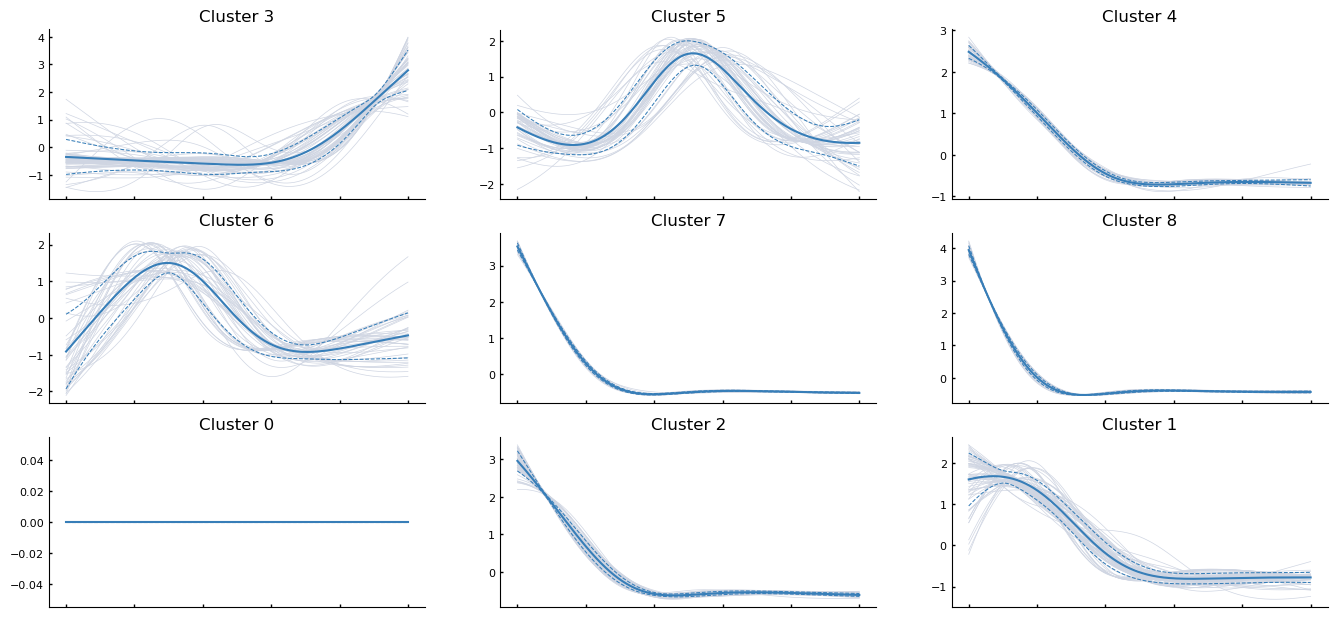

In [62]:
# of 
communities = palantir.presults.cluster_gene_trends(ery_mk_ad, 
    "ery", diff_degs, n_neighbors = 20)


palantir.plot.plot_gene_trend_clusters(ery_mk_ad, "ery")
plt.show()

## mk related genes

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


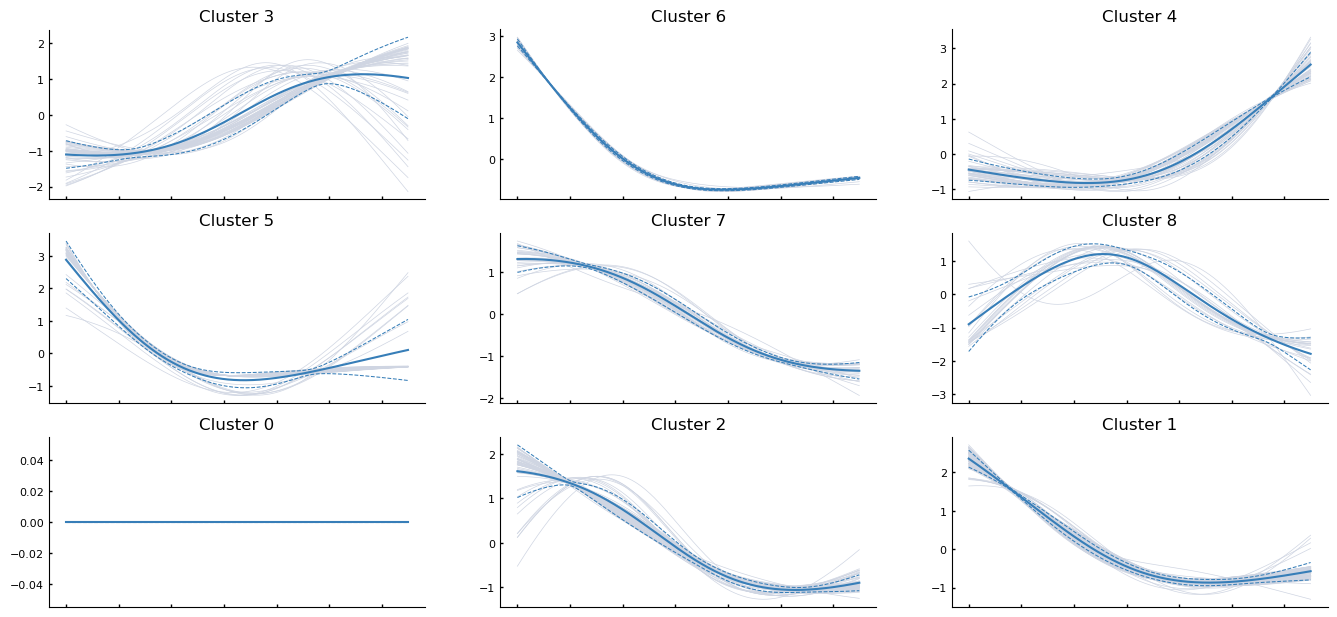

In [63]:
# of 
communities = palantir.presults.cluster_gene_trends(ery_mk_ad, 
    "mk", diff_degs, n_neighbors = 20)


palantir.plot.plot_gene_trend_clusters(ery_mk_ad, "mk")
plt.show()

### find gene with the highest correlation

In [9]:
from scipy.stats import pearsonr, spearmanr

In [18]:
from tqdm import tqdm

In [19]:
for gene in tqdm(diff_degs):
    pass

100%|██████████| 449/449 [00:00<00:00, 1342296.86it/s]


## ery trajectory

In [36]:
ery_ad = ery_mk_ad[ery_mk_ad.obsm['branch_masks']['ery']]
pseudotime = ery_ad.obs.palantir_pseudotime.values.reshape(-1,1)

(16078, 1) (16078, 449)


In [49]:
expression = ery_ad.layers['MAGIC_imputed_data']

ery_R = []
ery_Rou = []
i = 0

for i in tqdm(range(ery_mk_ad.shape[1])):
    ery_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    ery_Rou.append(spearmanr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
ery_R = np.array(ery_R)
ery_R = np.where(np.isnan((ery_R)), 0, ery_R)
ery_mk_ad.var['ery_Magic_pdt_r'] = ery_R

ery_Rou = np.array(ery_Rou)
ery_Rou = np.where(np.isnan((ery_Rou)), 0, ery_Rou)
ery_mk_ad.var['ery_Magic_pdt_spr'] = ery_Rou

  0%|          | 0/4814 [00:00<?, ?it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
  0%|          | 11/4814 [00:00<03:15, 24.54it/s]

100%|██████████| 4814/4814 [00:52<00:00, 91.60it/s] 


In [81]:
expression = ery_ad.X.A

ery_R = []
i = 0
for i in tqdm(range(ery_mk_ad.shape[1])):
    ery_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
ery_R = np.array(ery_R)
ery_R = np.where(np.isnan((ery_R)), 0, ery_R)
ery_mk_ad.var['ery_X_pdt_r'] = ery_R

  0%|          | 4/4814 [00:00<02:09, 37.18it/s]

  0%|          | 14/4814 [00:00<02:26, 32.80it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
100%|██████████| 4814/4814 [01:50<00:00, 43.70it/s] 


In [199]:
ery_top_genes = ery_mk_ad.var[['symbol','ery_Magic_pdt_spr', 'ery_Magic_pdt_r', 'ery_X_pdt_r']].sort_values('ery_Magic_pdt_r', ascending=False)
ery_genes = ery_top_genes.iloc[:10].index
ery_top_genes.head()

,symbol,ery_Magic_pdt_spr,ery_Magic_pdt_r,ery_X_pdt_r
Kcnn4,Kcnn4,0.906293,0.917591,0.262907
Mrpl52,Mrpl52,0.948014,0.914509,0.493579
Kel,Kel,0.967745,0.899340,0.398343
Gfi1b,Gfi1b,0.848910,0.888420,0.348225
Zdhhc14,Zdhhc14,0.913195,0.871559,0.205778


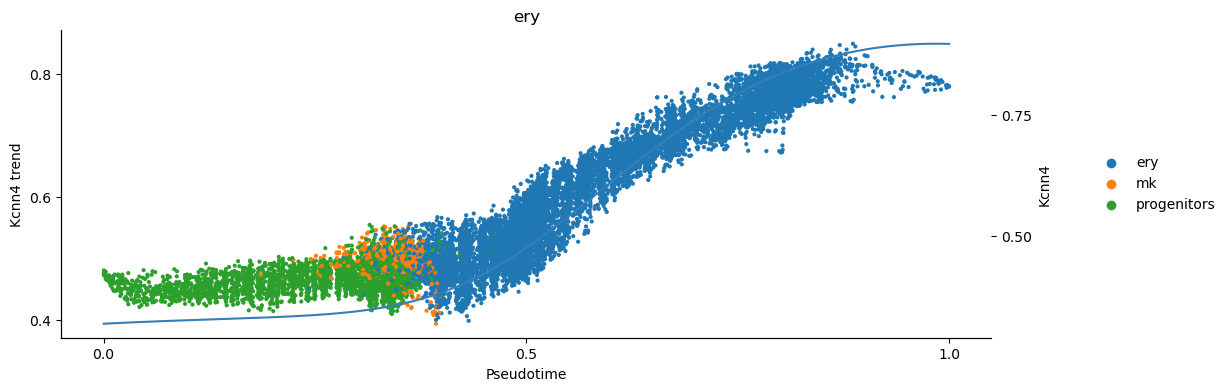

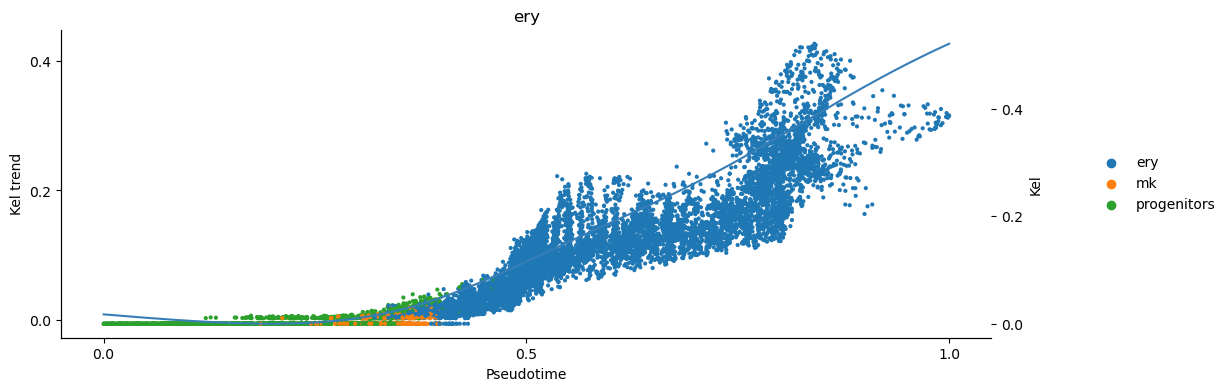

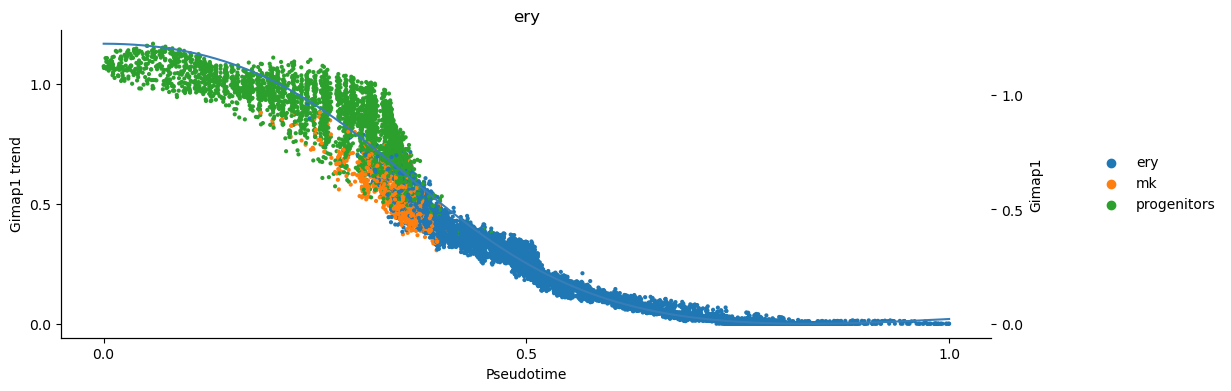

In [110]:
palantir.plot.plot_trend(ery_ad, "ery", "Kcnn4", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(ery_ad, "ery", "Kel", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(ery_ad, "ery", "Gimap1", color="branch", position_layer="MAGIC_imputed_data")
plt.show()

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1359: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(
/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1359: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(


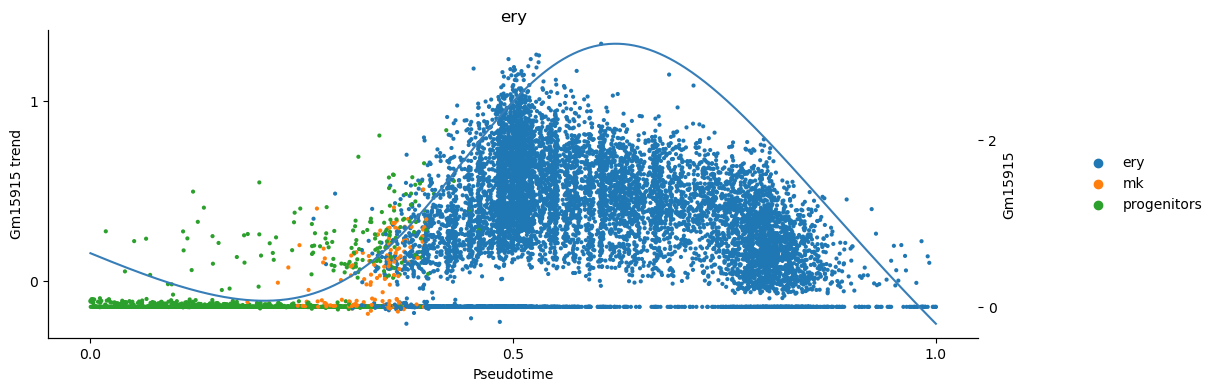

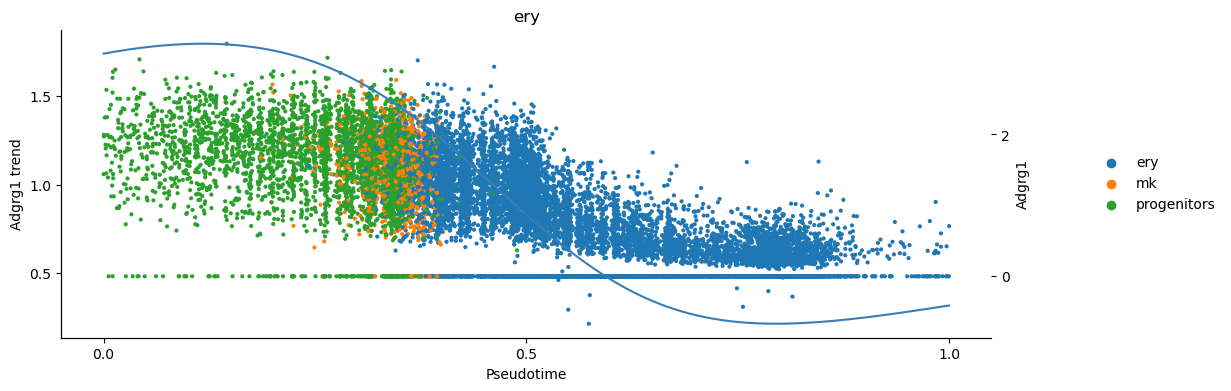

In [87]:
palantir.plot.plot_trend(ery_ad, "ery", "Gm15915", color="branch", position_layer="X")
palantir.plot.plot_trend(ery_ad, "ery", "Adgrg1", color="branch", position_layer="X")
plt.show()

## mk trajectory

In [88]:
mk_ad = ery_mk_ad[ery_mk_ad.obsm['branch_masks']['mk']]

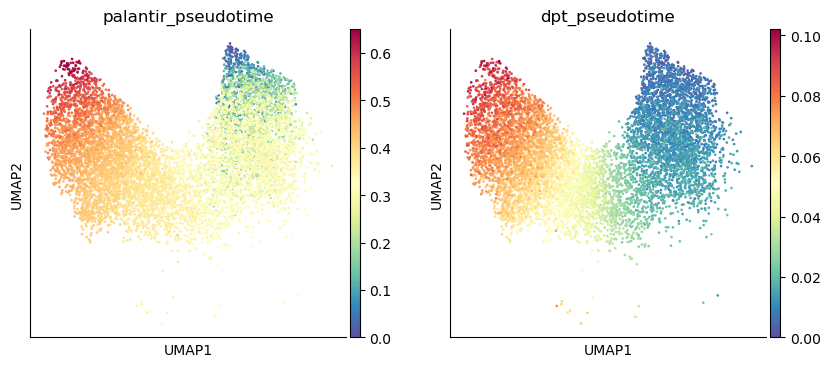

In [95]:
sc.pl.umap(mk_ad, color=['palantir_pseudotime', 'dpt_pseudotime'])

In [99]:
expression = mk_ad.layers['MAGIC_imputed_data']
pseudotime = mk_ad.obs.palantir_pseudotime.values.reshape(-1,1)

mk_R = []
mk_Rou = []
i = 0
for i in tqdm(range(ery_mk_ad.shape[1])):
    mk_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    mk_Rou.append(spearmanr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
mk_R = np.array(mk_R)
mk_R = np.where(np.isnan((mk_R)), 0, mk_R)
ery_mk_ad.var['mk_Magic_pdt_r'] = mk_R

mk_Rou = np.array(mk_Rou)
mk_Rou = np.where(np.isnan((mk_Rou)), 0, mk_Rou)
ery_mk_ad.var['mk_Magic_pdt_spr'] = mk_Rou

  0%|          | 0/4814 [00:00<?, ?it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
100%|██████████| 4814/4814 [00:02<00:00, 2286.72it/s]


In [90]:
expression = mk_ad.X.A

mk_R = []
i = 0
for i in tqdm(range(ery_mk_ad.shape[1])):
    mk_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
mk_R = np.array(mk_R)
mk_R = np.where(np.isnan((mk_R)), 0, mk_R)
ery_mk_ad.var['mk_X_pdt_r'] = mk_R

  0%|          | 0/4814 [00:00<?, ?it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
  5%|▌         | 259/4814 [00:00<00:03, 1299.93it/s]

100%|██████████| 4814/4814 [00:03<00:00, 1392.46it/s]


In [198]:
mk_top_genes = ery_mk_ad.var[['symbol', "mk_Magic_pdt_spr",'mk_Magic_pdt_r', 'mk_X_pdt_r']].sort_values('mk_Magic_pdt_r', ascending=False)
mk_genes = mk_top_genes.iloc[:10].index
mk_top_genes.head()

,symbol,mk_Magic_pdt_spr,mk_Magic_pdt_r,mk_X_pdt_r
Actb,Actb,0.958672,0.970605,0.515620
Crip1,Crip1,0.852100,0.909462,0.388007
Rabgap1l,Rabgap1l,0.957289,0.903642,0.619374
Plek,Plek,0.970385,0.898411,0.688870
Gp5,Gp5,0.953911,0.893919,0.512401


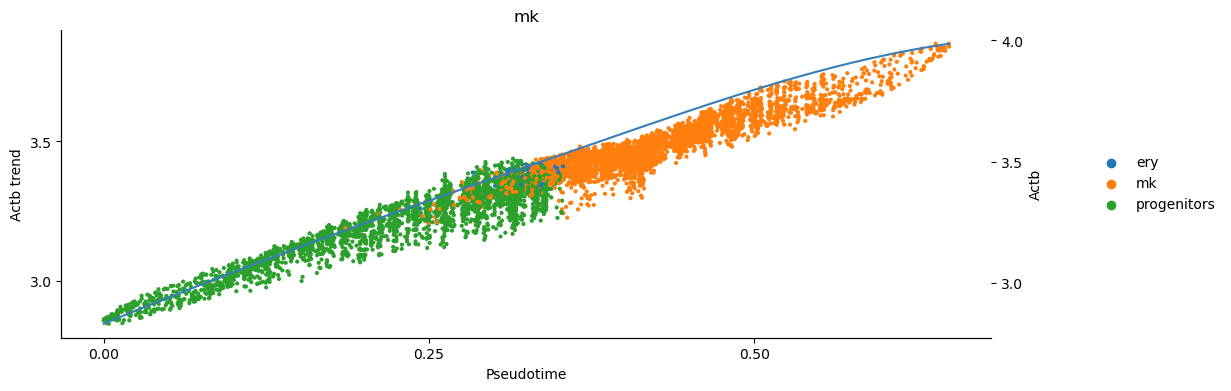

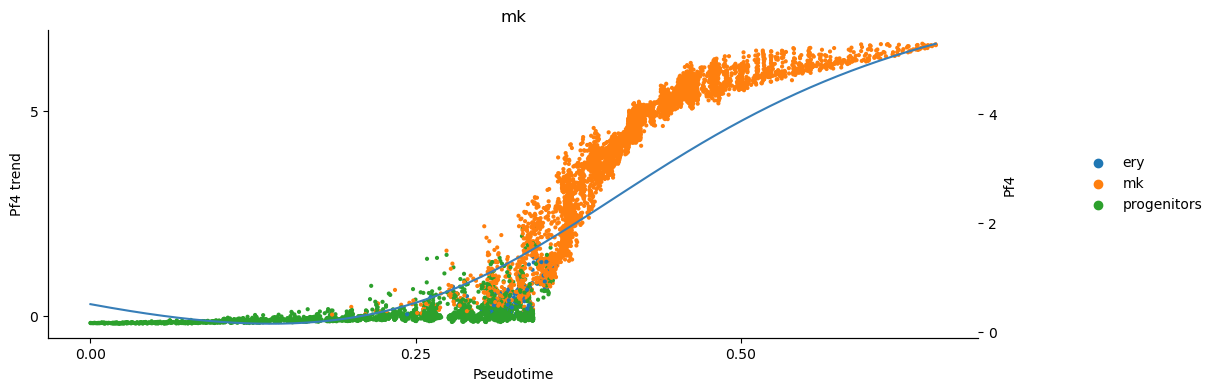

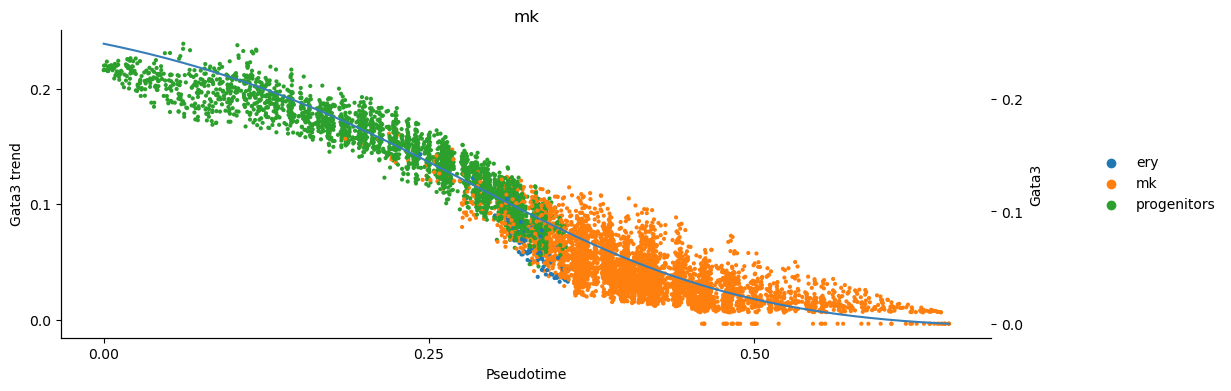

In [109]:
palantir.plot.plot_trend(mk_ad, "mk", "Actb", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(mk_ad, "mk", "Pf4", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(mk_ad, "mk", "Gata3", color="branch", position_layer="MAGIC_imputed_data")
plt.show()

In [106]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")

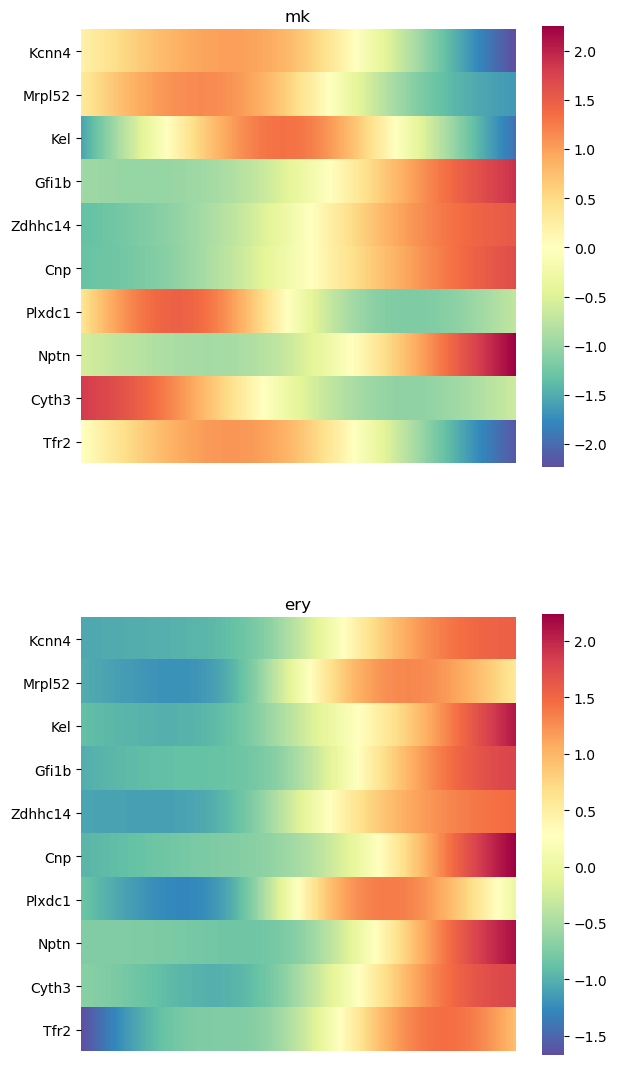

In [203]:
palantir.plot.plot_gene_trend_heatmaps(ery_mk_ad, ery_genes);

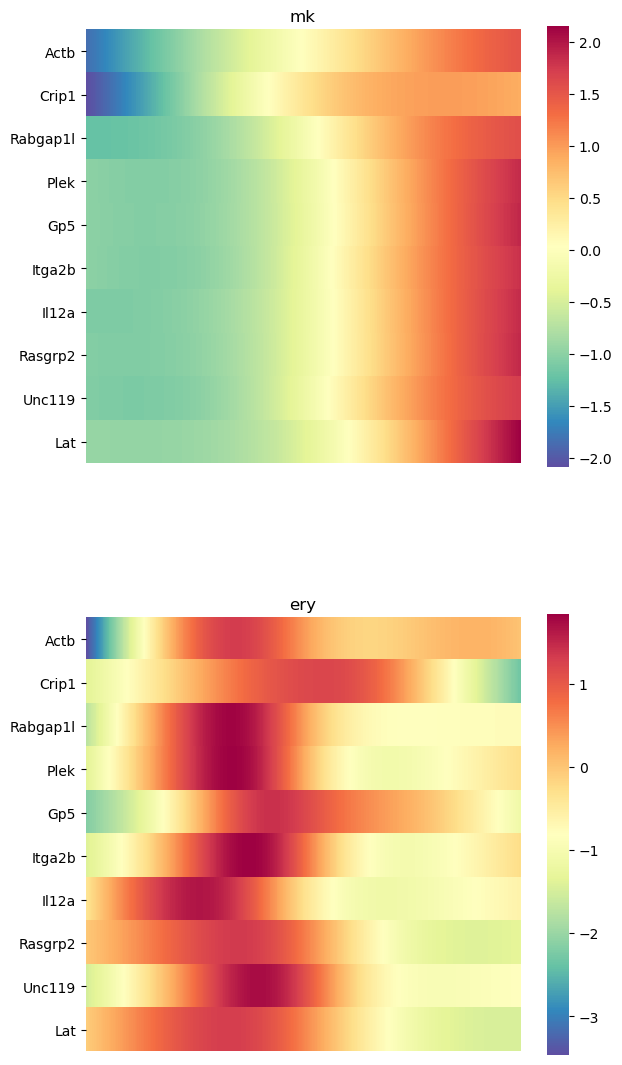

In [204]:
palantir.plot.plot_gene_trend_heatmaps(ery_mk_ad, mk_genes);

## Density

Let's take `Actb` for mk and `Kcnn4` for ery

In [112]:
# cell state coordinates
S = ery_mk_ad[:,['Actb', 'Kcnn4']].layers['MAGIC_imputed_data']

# rescale S
S = (S - S.min(0).reshape(-1,2)) / (S.max(0) - S.min(0)).reshape(-1,2)
ery_mk_ad.obsm['Actb_Kcnn4_scaled_S'] = S

In [156]:
S.min(0), S.max(0)

(array([0., 0.], dtype=float32), array([1., 1.], dtype=float32))

Text(0.5, 1.0, 'Kcnn4 - Ery')

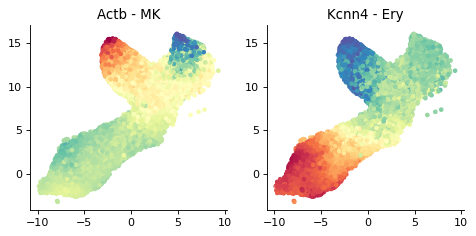

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(7,3), dpi=80)
X_umap = ery_mk_ad.obsm['X_umap']

axs[0].scatter(X_umap[:,0], X_umap[:,1], c=S[:,0], s=10)
axs[0].set_title("Actb - MK")

axs[1].scatter(X_umap[:,0], X_umap[:,1], c=S[:,1], s=10)
axs[1].set_title("Kcnn4 - Ery")

In [126]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")

Let visualize the density change over time

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Kcnn4 \n(Ery trajectory)')

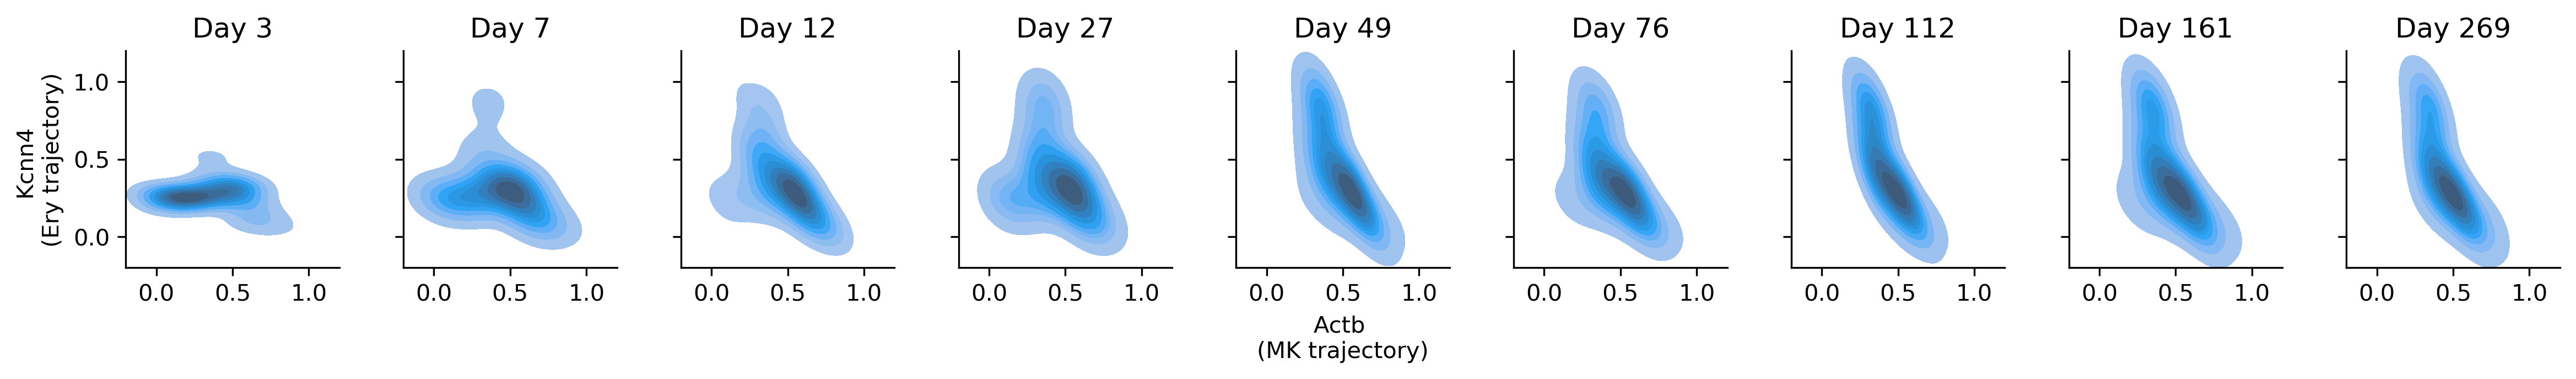

In [137]:
fig, axs = plt.subplots(1, 9, figsize=(19,1.7), dpi=300, sharey=True,  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(sorted(ery_mk_ad.obs['timepoint_tx_days'].unique())):
    ad_t = ery_mk_ad[ery_mk_ad.obs.query("`timepoint_tx_days` == @t").index]
    
    sns.kdeplot(x=ad_t.obsm['Actb_Kcnn4_scaled_S'][:,0], 
                y=ad_t.obsm['Actb_Kcnn4_scaled_S'][:,1], 
                bw_method = 0.6,
                fill=True, ax=axs[i_t])

    axs[i_t].set_xlabel('')
    axs[i_t].set_title('Day %d' %(t))
    
    axs[i_t].set_ylim(-0.2,1.2)
    axs[i_t].set_xlim(-0.2,1.2)
    axs[i_t].set_xticks([0,0.5,1.0])
axs[4].set_xlabel('Actb \n(MK trajectory)')
axs[0].set_ylabel('Kcnn4 \n(Ery trajectory)')

In [120]:
density_fn = gaussian_kde(S.T, bw_method=0.8)

In [121]:
density_fn

# fate probability

In [4]:
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [ ]:
ery_mk_ad.obsm_keys()

['DM_EigenVectors',
 'DM_EigenVectors_multiscaled',
 'X_diffmap',
 'X_pca',
 'X_pca_harmony',
 'X_pca_scaled',
 'X_umap',
 'X_umap_2d',
 'X_umap_3d',
 'X_umap_DM_2d',
 'X_umap_DM_3d',
 'branch_masks',
 'palantir_fate_probabilities',
 'Actb_Kcnn4_scaled_S']

In [138]:
ery_mk_ad.obsm['palantir_fate_probabilities']

,mk,ery
9mo_SIGAE3_AAACCCAAGACCTCAT-1-10x,0.590898,0.409102
9mo_SIGAE3_AAACGAAGTAACAGGC-1-10x,0.413496,0.586504
9mo_SIGAE3_AAACGAATCTACGGTA-1-10x,0.582110,0.417890
9mo_SIGAE3_AAACGCTAGCGTTCAT-1-10x,0.253105,0.746895
9mo_SIGAE3_AAACGCTTCCGTGCGA-1-10x,0.499395,0.500605
...,...,...
1276-SS2,0.500839,0.499161
1281-SS2,0.500839,0.499161
1282-SS2,0.528691,0.471309
1285-SS2,0.405344,0.594656


## density of fate probability, pseudotime, or magic smoothed genes

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'mk trajectory \n Density')

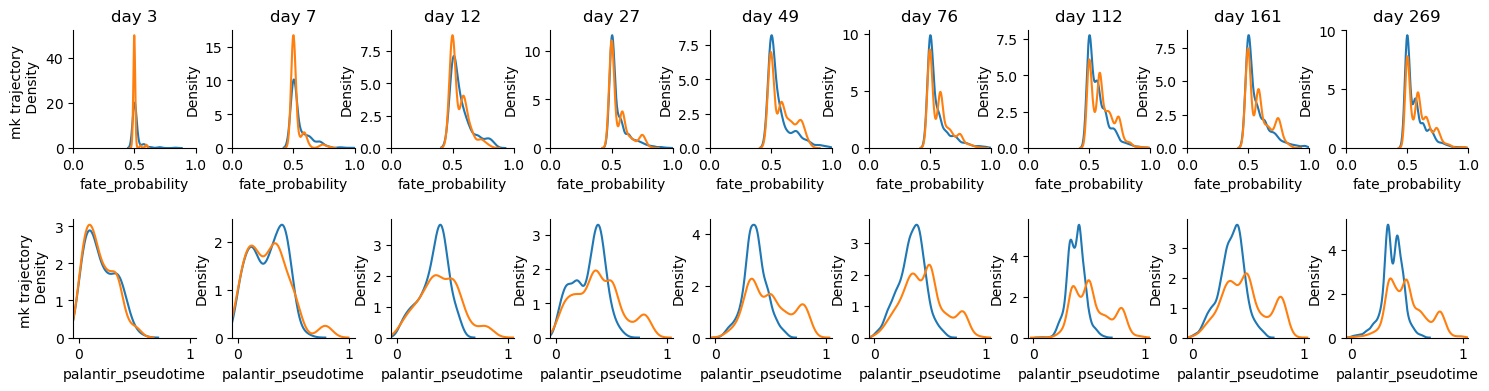

In [ ]:
fig, axs = plt.subplots(2, 9, figsize=(18,4), gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(sorted(ery_mk_ad.obs['timepoint_tx_days'].unique())):
    ad_t = ery_mk_ad[ery_mk_ad.obs.query("`timepoint_tx_days` == @t").index]

    mk_adt = ad_t[ad_t.obsm['branch_masks']['mk']]
    ery_adt = ad_t[ad_t.obsm['branch_masks']['ery']]

    #  fate probability density
    sns.kdeplot(mk_adt.obsm['palantir_fate_probabilities']['mk'], ax=axs[0,i_t], label='mk')
    sns.kdeplot(ery_adt.obsm['palantir_fate_probabilities']['ery'], ax=axs[0,i_t], label='ery')

    #  plt
    sns.kdeplot(mk_adt.obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='mk')
    sns.kdeplot(ery_adt.obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='ery')


    
    axs[0,i_t].set_title('day %d' %t)
    axs[0,i_t].set_xlabel('fate_probability')
    axs[0,i_t].set_xlim(0,1)
    axs[1,i_t].set_xlabel('palantir_pseudotime')
    axs[1,i_t].set_xlim(-0.05,1.05)

axs[0,0].legend(ncol=1)

axs[0,0].set_ylabel('mk trajectory \n Density')
axs[1,0].set_ylabel('mk trajectory \n Density')


In [147]:
# (n_cell,) -> (n_cell,2)
pseudotime = ery_mk_ad.obs.palantir_pseudotime.values.reshape(-1,1)
pseudotime = np.broadcast_to(pseudotime, (pseudotime.shape[0],2))

# make sure the 
Fate_P = ery_mk_ad.obsm['palantir_fate_probabilities'].values

In [242]:
# make sure the pseudotime and fate probability has the same shape
Fate_coord = np.multiply(Fate_P**1.5, pseudotime**0.3) 
Fate_coord.min(0), Fate_coord.max(0)

(array([0., 0.]), array([0.83727774, 0.94777967]))

In [243]:
# rescale to 0,1
Fate_coord = (Fate_coord - Fate_coord.min(0).reshape(-1,2)) / (Fate_coord.max(0) - Fate_coord.min(0)).reshape(-1,2)
Fate_coord.min(0), Fate_coord.max(0)

(array([0., 0.]), array([1., 1.]))

Text(0.5, 1.0, 'Kcnn4 dpt - Ery')

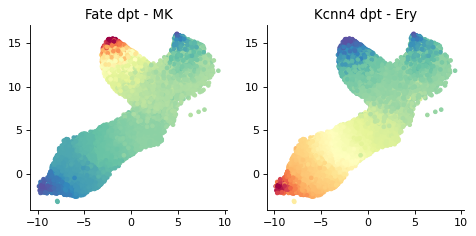

In [244]:
fig, axs = plt.subplots(1,2, figsize=(7,3), dpi=80)
X_umap = ery_mk_ad.obsm['X_umap']

coords = Fate_coord #ery_mk_ad.obsm['Fate_scaled_dpt']

axs[0].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,0], s=10)
axs[0].set_title("Fate dpt - MK")

axs[1].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,1], s=10)
axs[1].set_title("Kcnn4 dpt - Ery")

In [245]:
ery_mk_ad.obsm['Fate_scaled_dpt'] = Fate_coord

Text(0, 0.5, 'Ery trajectory)')

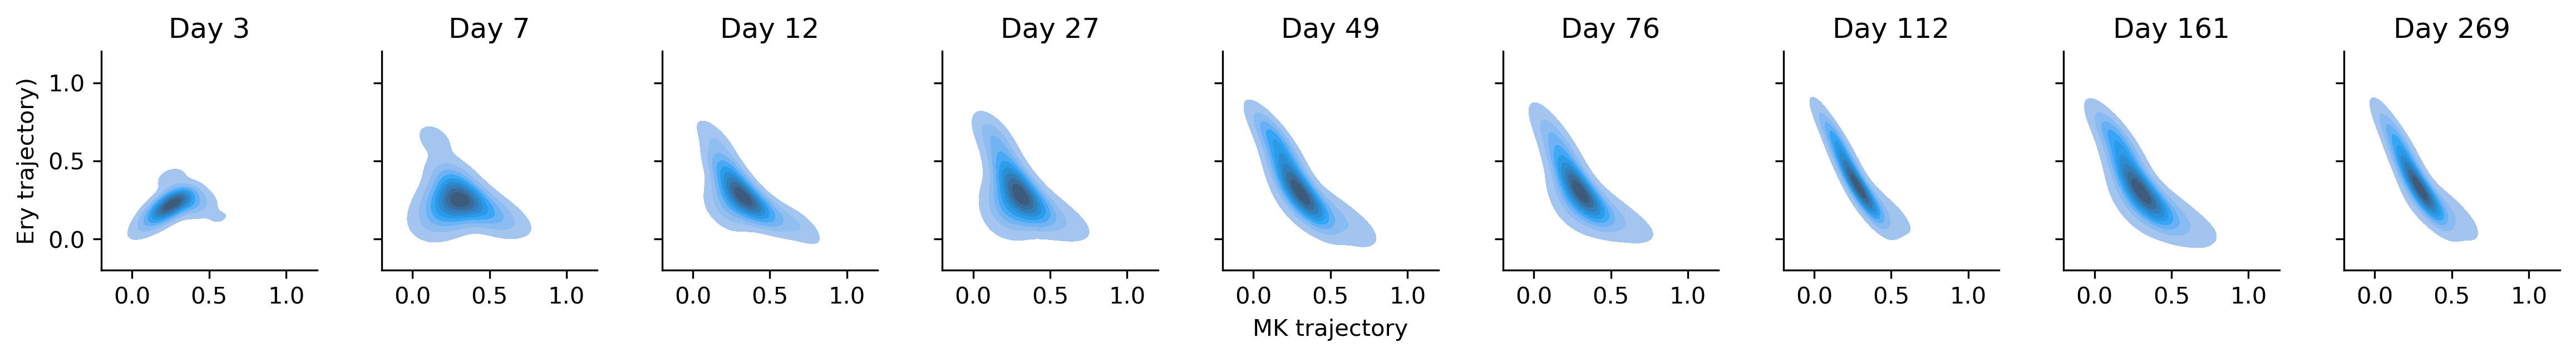

In [246]:
fig, axs = plt.subplots(1, 9, figsize=(19,1.7), dpi=300, sharey=True,  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(sorted(ery_mk_ad.obs['timepoint_tx_days'].unique())):
    ad_t = ery_mk_ad[ery_mk_ad.obs.query("`timepoint_tx_days` == @t").index]
    
    sns.kdeplot(x=ad_t.obsm['Fate_scaled_dpt'][:,0], 
                y=ad_t.obsm['Fate_scaled_dpt'][:,1], 
                bw_method = 0.7,
                fill=True, ax=axs[i_t])

    axs[i_t].set_xlabel('')
    axs[i_t].set_title('Day %d' %(t))
    
    axs[i_t].set_ylim(-0.2,1.2)
    axs[i_t].set_xlim(-0.2,1.2)
    axs[i_t].set_xticks([0,0.5,1.0])
    
axs[4].set_xlabel('MK trajectory')
axs[0].set_ylabel('Ery trajectory)')

Text(0.5, 1.0, 'Fate - Ery')

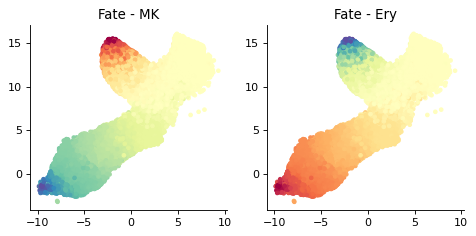

In [247]:
fig, axs = plt.subplots(1,2, figsize=(7,3), dpi=80)
X_umap = ery_mk_ad.obsm['X_umap']

coords = ery_mk_ad.obsm['palantir_fate_probabilities'].values

axs[0].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,0], s=10)
axs[0].set_title("Fate - MK")

axs[1].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,1], s=10)
axs[1].set_title("Fate - Ery")

In [248]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")